# Stateful Event-Driven Agent



A stateful agent moves through explicit stages based on events and graph transitions.



## Stack

- Framework: LangGraph state machine

- LLM: local Ollama via `ChatOllama(model="llama3.1:latest")`

- Pattern goal: durable workflow state



## When to use it

- Tasks span multiple steps, retries, or approvals

- You need durable state and predictable transitions

## Architecture



```mermaid

graph TD

    N[New] --> R[Researching]

    R --> D[Drafting]

    D --> V[Review]

    V --> F[Done]

```

In [ ]:
from visual_diagram_helper import render_svg_flow



nodes = [

    ("new", "New", 60, 170, "#bfdbfe"),

    ("research", "Researching", 290, 170, "#bbf7d0"),

    ("draft", "Drafting", 520, 170, "#fde68a"),

    ("review", "Review", 750, 170, "#fecaca"),

    ("done", "Done", 980, 170, "#ddd6fe"),

]

edges = [

    ("new", "research"),

    ("research", "draft"),

    ("draft", "review"),

    ("review", "done"),

]



render_svg_flow("Stateful Event-Driven Visual Architecture", nodes, edges, width=1220, height=340)

In [ ]:
# Reload shared helpers so any edits to agent_patterns_common.py take effect

# without needing to restart the kernel.

import importlib

import agent_patterns_common



importlib.reload(agent_patterns_common)

print("agent_patterns_common reloaded.")

### Stateful Event-Driven State Graph

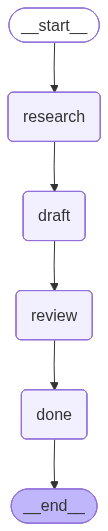

{"level": "INFO", "event_type": "state_transition", "next_status": "researching"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Return EXACTLY 3 research bullets.\nEach bullet starts with '- '.\nRequest: Prepar"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "state_transition", "next_status": "drafting"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Write EXACTLY 3 draft bullets from notes.\nEach bullet starts with '- '.\nNotes:\nH"}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "state_transition", "next_status": "review"}
{"level": "INFO", "event_type": "llm_invoke_start", "attempt": 1, "prompt_preview": "Produce final response as EXACTLY 4 bullet points.\nEach bullet starts with '- '."}
{"level": "INFO", "event_type": "llm_invoke_success", "attempt": 1}
{"level": "INFO", "event_type": "state_transitio

{'request': 'Prepare an explanation of event-driven AI agents',
 'status': 'done',
 'notes': 'Here are three research bullets on event-driven AI agents:\n\n- **Event-Driven Architecture**: Event-driven AI agents utilize a decentralized architecture where events trigger responses from the agent. This approach enables real-time processing and adaptation to changing environments, allowing for more efficient decision-making.\n\n- **Contextual Understanding**: Event-driven AI agents can capture contextual information associated with each event, enabling them to understand the nuances of complex situations. By incorporating contextual data, these agents can make more informed decisions and respond accordingly.\n\n- **Autonomous Decision-Making**: Event-driven AI agents are designed to operate autonomously, making decisions based on real-time events without human intervention. This allows for faster response times and improved adaptability in dynamic environments, where traditional rule-based

In [ ]:
from langgraph.graph import END, START, StateGraph



from agent_pattern_states import StatefulAgentState

from agent_patterns_common import (

    append_history,

    build_checkpointer,

    get_local_llm,

    invoke_with_retry,

    log_event,

    render_state_graph,

)





llm = get_local_llm()





def research_node(state: StatefulAgentState) -> StatefulAgentState:

    log_event("info", "state_transition", next_status="researching")

    prompt = (

        "Return EXACTLY 3 research bullets.\n"

        "Each bullet starts with '- '.\n"

        f"Request: {state['request']}"

    )

    return {

        "status": "researching",

        "notes": invoke_with_retry(llm, prompt),

        "history": append_history(state.get("history"), "Research completed"),

    }





def draft_node(state: StatefulAgentState) -> StatefulAgentState:

    log_event("info", "state_transition", next_status="drafting")

    prompt = (

        "Write EXACTLY 3 draft bullets from notes.\n"

        "Each bullet starts with '- '.\n"

        f"Notes:\n{state['notes']}"

    )

    return {

        "status": "drafting",

        "draft": invoke_with_retry(llm, prompt),

        "history": append_history(state["history"], "Draft created"),

    }





def review_node(state: StatefulAgentState) -> StatefulAgentState:

    log_event("info", "state_transition", next_status="review")

    prompt = (

        "Produce final response as EXACTLY 4 bullet points.\n"

        "Each bullet starts with '- '.\n"

        f"Draft:\n{state['draft']}"

    )

    return {

        "status": "review",

        "final_answer": invoke_with_retry(llm, prompt),

        "history": append_history(state["history"], "Draft reviewed"),

    }





def done_node(state: StatefulAgentState) -> StatefulAgentState:

    log_event("info", "state_transition", next_status="done")

    return {

        "status": "done",

        "history": append_history(state["history"], "Workflow complete"),

    }





builder = StateGraph(StatefulAgentState)

builder.add_node("research", research_node)

builder.add_node("draft", draft_node)

builder.add_node("review", review_node)

builder.add_node("done", done_node)

builder.add_edge(START, "research")

builder.add_edge("research", "draft")

builder.add_edge("draft", "review")

builder.add_edge("review", "done")

builder.add_edge("done", END)



graph = builder.compile(checkpointer=build_checkpointer())

render_state_graph(graph, "Stateful Event-Driven State Graph")



result = graph.invoke(

    {

        "request": "Prepare an explanation of event-driven AI agents",

        "status": "new",

        "notes": "",

        "draft": "",

        "final_answer": "",

        "history": [],

    },

    config={"configurable": {"thread_id": "stateful-agent-demo"}},

)



result

## Design insight



Explicit state is what makes long-running automation predictable. Once the workflow matters, model the transitions directly instead of hiding them in prompts.